<a href="https://colab.research.google.com/github/jasminealyaa1212/PCD-Assignment-2/blob/main/PCD__Assignment02_558659_Jasmine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital Image Processing Assignment 2**

blurry image

Mounted at /content/drive
Image Shape: 3468 3468


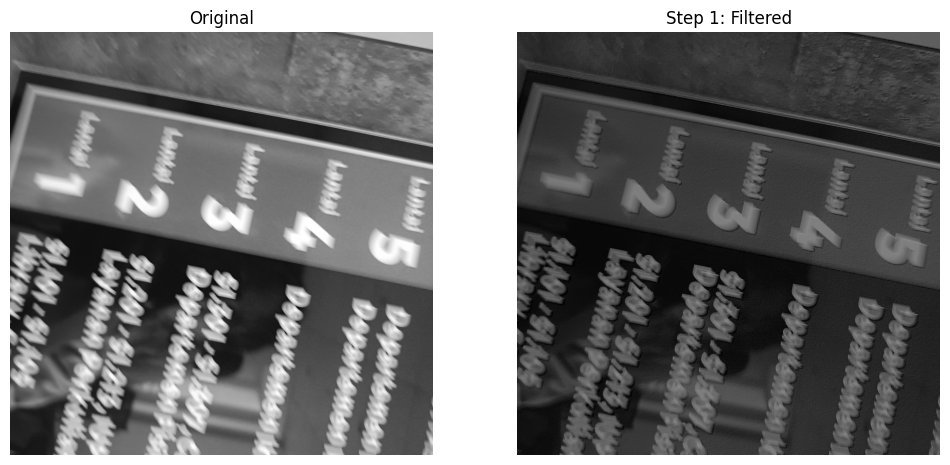

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/semester 3/Digital Image Processing/Assignment 2/blurry image.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

linear = np.array([[-2, -1, 0],
                    [-1.3, 0.5, 1],
                    [0.3, 1, 2]])

filter = cv2.filter2D(src=img, ddepth=-1, kernel=linear)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filter]
titles = ['Original', 'Step 1: Filtered']

plt.figure(figsize=(12, 12))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


dark image

Mounted at /content/drive
Image Shape: 3468 3468


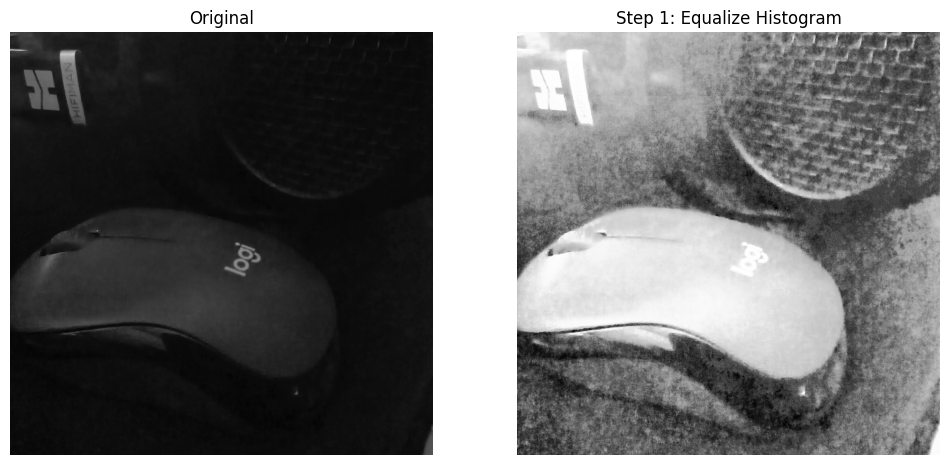

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/semester 3/Digital Image Processing/Assignment 2/dark image.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

filter = cv2.equalizeHist(img)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filter]
titles = ['Original', 'Step 1: Equalize Histogram']

plt.figure(figsize=(12, 12))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

bright image

Mounted at /content/drive
Image Shape: 3312 3312


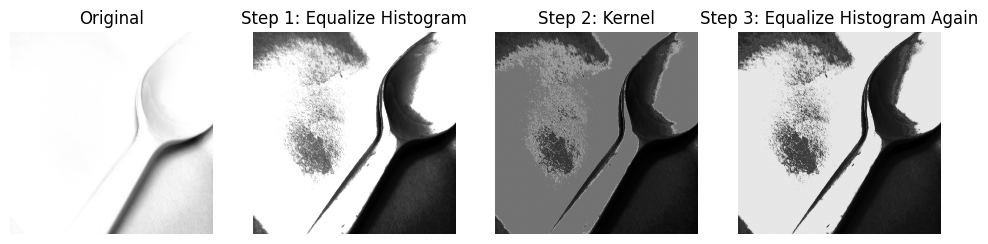

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/semester 3/Digital Image Processing/Assignment 2/bright image.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

filtered = cv2.equalizeHist(img)
linear = np.array([[-1, -1, -1],
                    [-1, 8.45, -1],
                    [-1, -1, -1]])
filter = cv2.filter2D(src=filtered, ddepth=-1, kernel=linear)

again = cv2.equalizeHist(filter)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filtered, filter, again]
titles = ['Original', 'Step 1: Equalize Histogram', 'Step 2: Kernel', 'Step 3: Equalize Histogram Again']


plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

low contrast

Mounted at /content/drive
Image Shape: 3122 3122


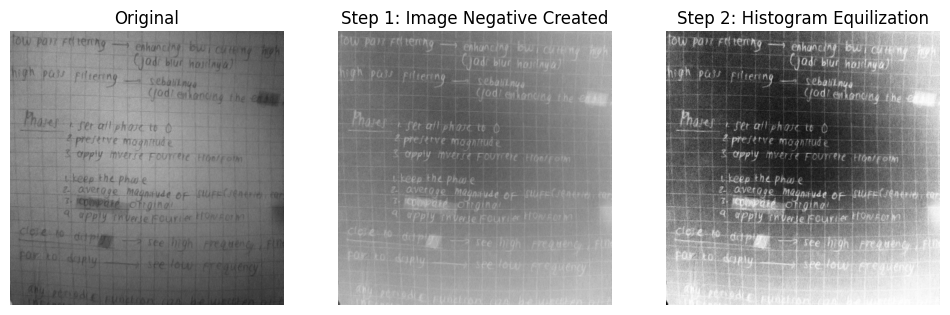

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/semester 3/Digital Image Processing/Assignment 2/low contrast image.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

negative_image = 255 - img
filtered = cv2.equalizeHist(negative_image)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, negative_image, filtered]
titles = ['Original', 'Step 1: Image Negative Created', 'Step 2: Histogram Equilization']

plt.figure(figsize=(12, 12))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# **Report Analysis**

**A. Down Sampling**

1.	Average

  kernel = np.ones((8, 8)) / 64

  return ndimage.convolve(image, kernel)[::8, ::8]

  It divides the image into 64x64 grid, then box them into 8x8 grid, then within each 8x8 grid, calculate the average of the 8 pixels in it. Then replace the 8 pixels with just 1 value that is the average. It will then turn the image that’s originally 64x64 to 8x8. This makes the resolution less but the image still looks recognizable.


2.	Median

  return ndimage.median_filter(image, size=8)[::8, ::8]

  It divides the image into 64x64 grid, then box them into 8x8 grid, then within each 8x8 grid, calculate the mean of the 8 pixels in it. Then replace the 8 pixels with just 1 value that is the mean. It will then turn the image that’s originally 64x64 to 8x8. Like the average, this makes the resolution less but the image still looks recognizable. Although I think it’s a little less like the original, since we’re taking the mean, which isn’t necessarily a perfect representation of the entire 8x8 pixels we’re shrinking.

3.	Max

  return ndimage.maximum_filter(image, size=8)[::8, ::8]

  It divides the image into 64x64 grid, then box them into 8x8 grid, then within each 8x8 grid, calculate the max value of the 8 pixels in it. Then replace the 8 pixels with just 1 value that is the max one. It will then turn the image that’s originally 64x64 to 8x8. Unlike the average and mean one, this makes the image a lot less recognizable, and overall brighter since we’re only taking the maximum value from each 8x8 grid. As we can see here, dolly’s face turns into a strange bright mix that’s hardly recognizable anymore. The eye part especially becomes totally different too.


**B. Up Sampling**

  For the up sampling, I used opencv’s pre compiled algorithms that I added on the top like this (import cv2) so I can access the nearest neighbor, bilinear, and bicubic up sampling algorithms easily.

1.	Nearest neighbor

    def nn_upsampling(image):

    h, w = image.shape

    return cv2.resize(image, (w * 8, h * 8), interpolation=cv2.INTER_NEAREST)

    In the nn_upsampling function, the code gets the image dimensions with h, w = image.shape and multiplies both by 8 to build a target grid size of (w * 8, h * 8). Passing interpolation=cv2.INTER_NEAREST into cv2.resize() triggers opencv’s nearest neighbor algorithm. When stretching an image 8x, opencv creates 63 empty pixel slots for every original pixel. This algorithm maps each new empty coordinate back to the original image grid, rounds to the nearest whole pixel position, and copies that exact intensity value over without doing any blending math. Because whole blocks of 64 new pixels end up copying the exact same original value, the upscaled image turns into giant, visible pixel squares with rough edges (although the result is a biiit invisible to see to the naked eye).


2.	Bilinear

    def bilinear_upsampling(image):

    h, w = image.shape

    return cv2.resize(image, (w * 8, h * 8), interpolation=cv2.INTER_LINEAR)


    The bilinear_upsampling function uses the same (w * 8, h * 8) target grid dimensions, but switches the algorithm flag to interpolation=cv2.INTER_LINEAR. When a new missing pixel lands between original pixels, opencv looks at its 4 closest neighbors (a 2x2 pixel grid). It performs linear interpolation twice: first it calculates distance-weighted averages horizontally along the top and bottom rows, and then it averages those results vertically. If a missing pixel is closer to the top-left neighbor, that top-left pixel gets a stronger weight in the final color calculation. This distance-weighted blending wipes out hard pixel boundaries to create smooth color transitions, but because it relies on basic straight-line averages, sharp contrast edges get smoothed out and end up looking a bit soft or fuzzy.

3.	Bicubic

    def bicubic_upsampling(image):

    h, w = image.shape

    return cv2.resize(image, (w * 8, h * 8), interpolation=cv2.INTER_CUBIC)

    In bicubic_upsampling, the code scales the array to (w * 8, h * 8) using interpolation=cv2.INTER_CUBIC. Instead of just looking at 4 pixels, Bicubic expands the search area to a 4x4 grid of 16 surrounding original pixels. It uses third-order polynomials (cubic spline curves) rather than straight lines to estimate missing pixel values. By evaluating 16 surrounding pixels at once, the algorithm tracks how pixel intensity values are changing (their slopes) across the neighborhood. This allows it to reconstruct smooth curves and sharp edge transitions much more accurately. At an 8x expansion, Bicubic produces the cleanest visual result it eliminates blocky pixelation while keeping edge details crisp, avoiding the extra blur that Bilinear does.



